# Customer Segmentation Using Clustering

## Problem Statement

The objective of this project is to segment wholesale customers based on their purchasing behavior across different product categories. Since the dataset does not provide predefined customer groups, unsupervised clustering techniques are used to identify customers with similar purchasing patterns.

Two clustering algorithms are implemented and compared:

- K-Means Clustering
- Agglomerative Hierarchical Clustering

The clustering results are evaluated using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index. PCA and t-SNE are also used to visualize the identified customer groups.

In [1]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering and preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering

# Clustering evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
#Loading the Dataset
df = pd.read_csv("Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
# Display dataset dimensions
print("Shape:", df.shape)

# Display column names and data types
df.info()

Shape: (440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [4]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Number of duplicate rows: 0


### Observation

The dataset contains 440 records and 8 numerical features, with all columns having complete data. No missing values or duplicate records were found, so no missing-value imputation or duplicate removal is required at this stage. The dataset can therefore proceed to exploratory data analysis.

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution and relationships between customer purchasing features before applying clustering algorithms.

In [5]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


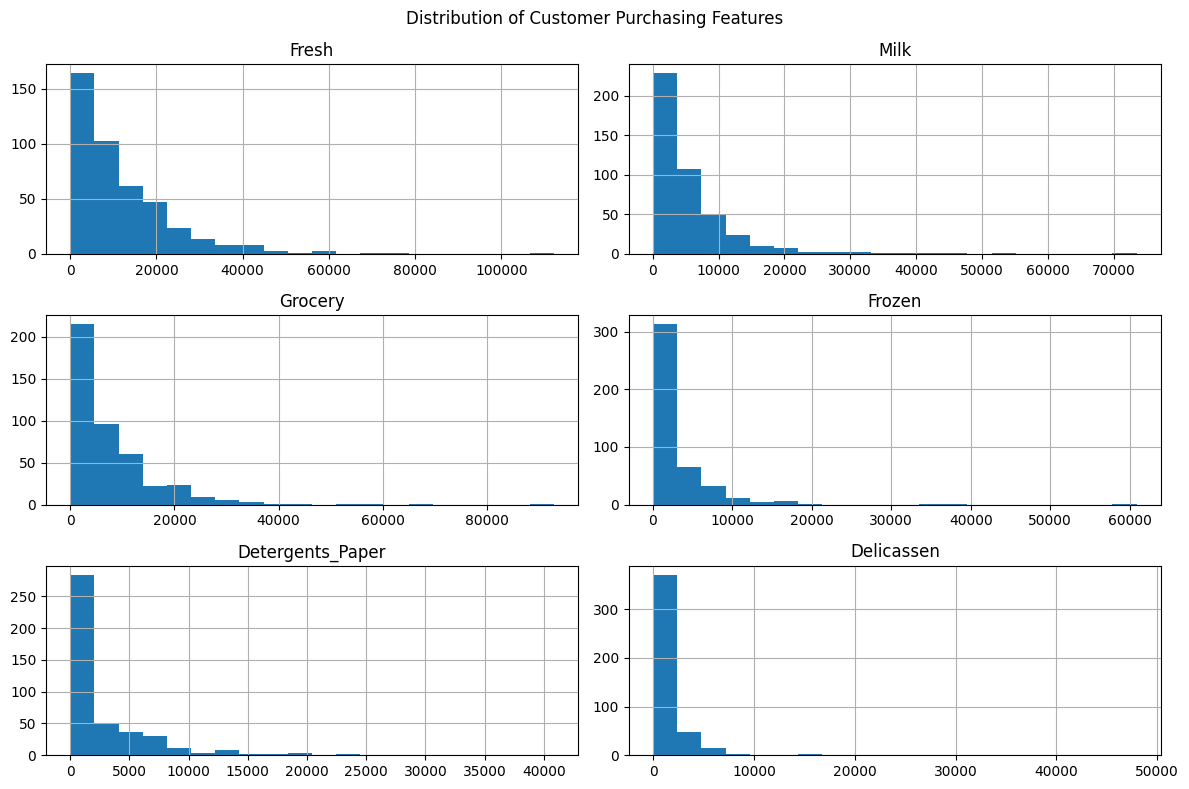

In [6]:
# Select purchasing behavior features
purchase_features = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

# Plot feature distributions
df[purchase_features].hist(figsize=(12, 8), bins=20)

plt.suptitle("Distribution of Customer Purchasing Features")
plt.tight_layout()
plt.show()

### 4.1 Scatter Plot

A scatter plot is used to examine the relationship between two purchasing categories. `Grocery` and `Detergents_Paper` are selected because they show a strong positive correlation in the correlation matrix.

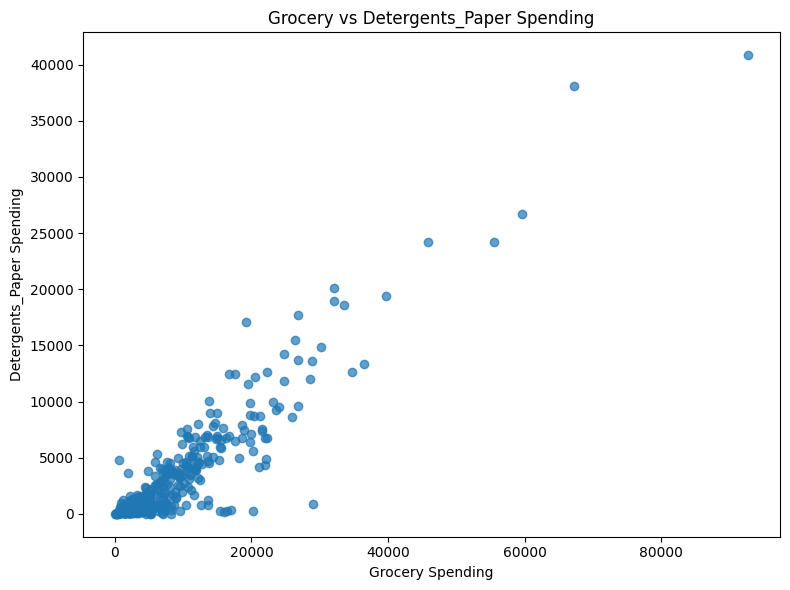

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Grocery'],
    df['Detergents_Paper'],
    alpha=0.7
)

plt.title("Grocery vs Detergents_Paper Spending")
plt.xlabel("Grocery Spending")
plt.ylabel("Detergents_Paper Spending")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a clear positive relationship between Grocery and Detergents_Paper spending. Most observations are concentrated at lower spending levels, while a smaller number of customers have substantially higher spending in both categories.

### 4.2 Pair Plot of Purchasing Features

A pair plot is used to examine the pairwise relationships and individual distributions of all six purchasing features. This provides a broader view of the relationships that may influence clustering.

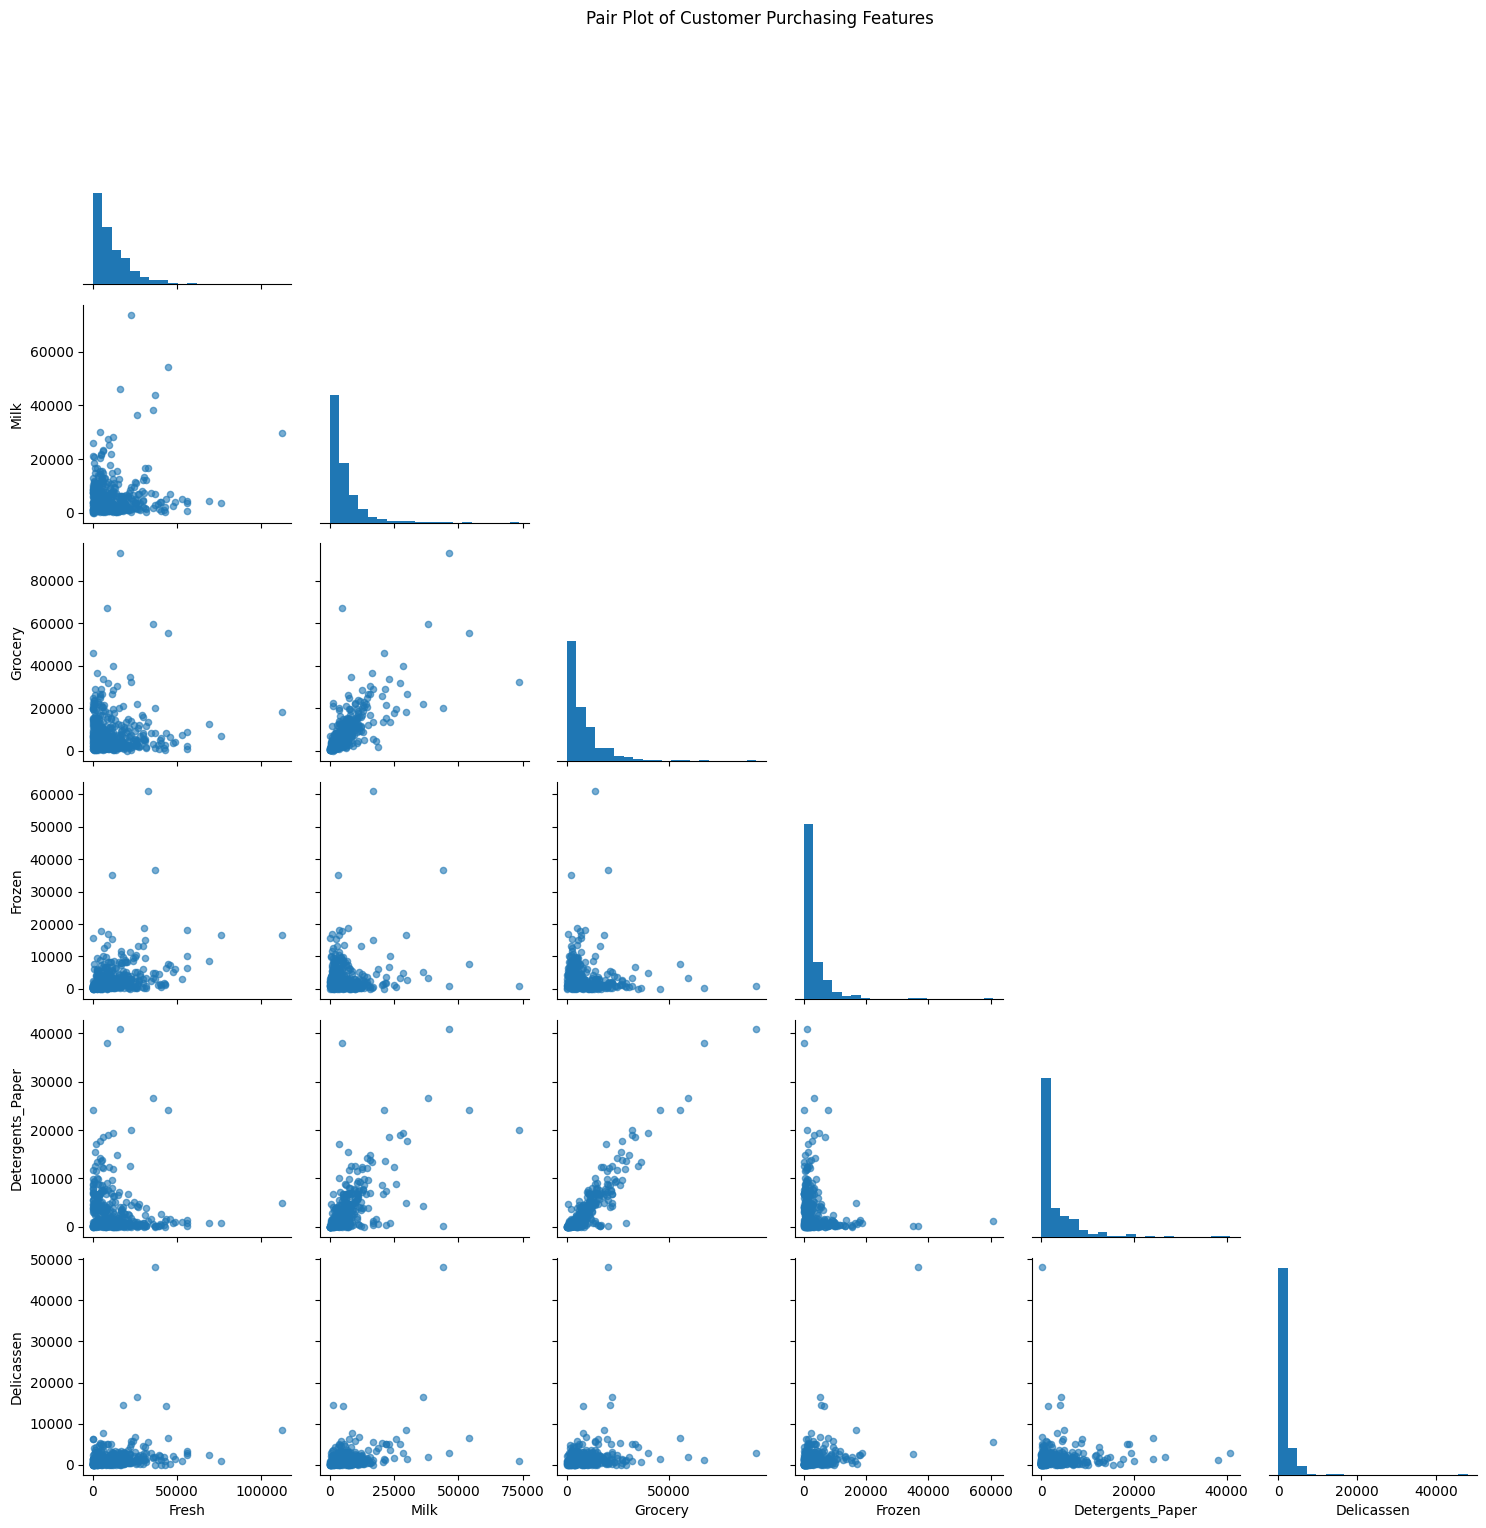

In [8]:
# Pair plot of all six purchasing features
pair_grid = sns.PairGrid(
    df[purchase_features],
    corner=True
)

pair_grid.map_lower(plt.scatter, alpha=0.6, s=20)
pair_grid.map_diag(plt.hist, bins=20)

pair_grid.fig.suptitle(
    "Pair Plot of Customer Purchasing Features",
    y=1.02
)

plt.show()

### Observation

The pair plot shows that the purchasing features are strongly right-skewed and have different ranges. It also shows stronger pairwise relationships among some categories, particularly Grocery with Detergents_Paper and Milk with Grocery, while several other pairs show weaker relationships.

### Observation

The distributions of all six purchasing features are strongly right-skewed. Most customers have relatively low to moderate spending, while a smaller number of customers show substantially higher spending values. This is particularly noticeable for features such as Fresh, Milk, Grocery, and Frozen.

The long right tails indicate the presence of high-value observations, which will be examined further using an outlier analysis. The different spreads across the features also support the need for feature scaling before clustering.

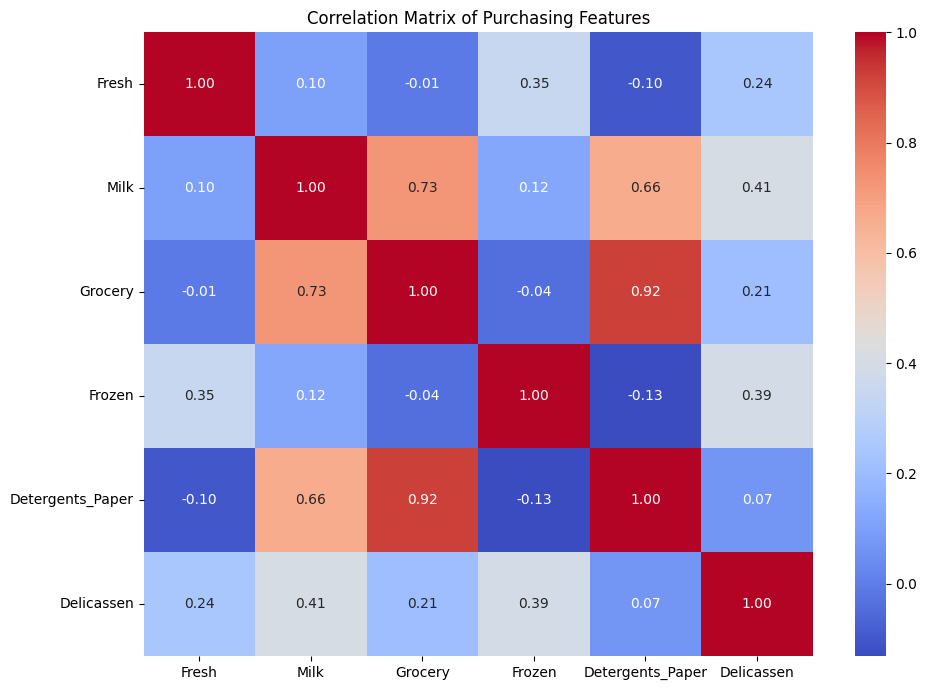

In [9]:
# Calculate correlations between purchasing features
correlation_matrix = df[purchase_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Purchasing Features")
plt.tight_layout()
plt.show()

#### Observation

The correlation matrix shows positive relationships between several purchasing categories, particularly Milk, Grocery, and Detergents_Paper. This indicates that customers with higher spending in one category may also tend to have higher spending in some related categories. However, the relationships vary across features, highlighting differences in customer purchasing patterns.

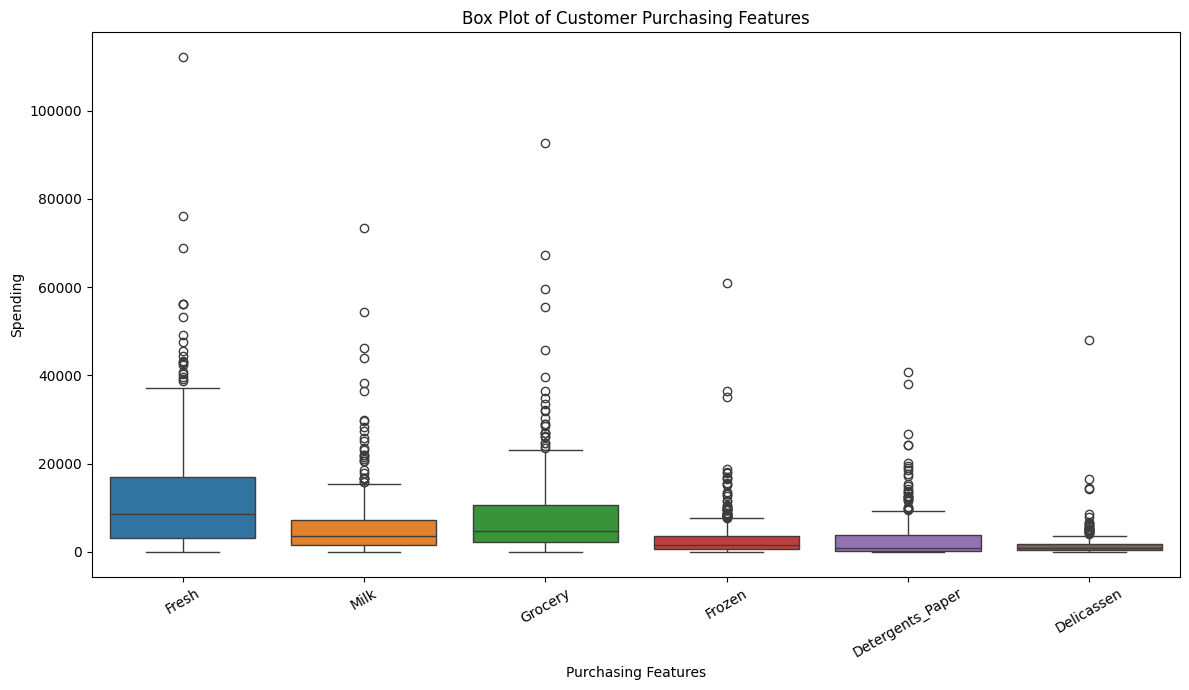

In [10]:
plt.figure(figsize=(12, 7))

sns.boxplot(data=df[purchase_features])

plt.title("Box Plot of Customer Purchasing Features")
plt.xlabel("Purchasing Features")
plt.ylabel("Spending")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Observation

The box plots show a considerable number of high-value observations across all six purchasing features. `Fresh`, `Milk`, and `Grocery` contain particularly large values beyond their upper whiskers, while `Frozen`, `Detergents_Paper`, and `Delicassen` also contain several high-value observations.

These observations may represent genuine differences in customer purchasing behavior rather than incorrect data. Therefore, they will not be removed solely based on the box plot. Feature scaling will be applied before clustering so that features with larger numerical ranges do not dominate the distance calculations.

## 5. Data Preprocessing

Data preprocessing is performed to prepare the purchasing features for clustering. The `Channel` and `Region` columns are not used as clustering features because the objective is to group customers based on their purchasing behavior.

The six product-category spending features are selected and standardized so that differences in their numerical scales do not disproportionately influence distance-based clustering algorithms.

### 5.1 Feature Selection

The following six features represent customer spending across different product categories and are used as input features for clustering.

In [11]:
purchase_features = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

X = df[purchase_features]

X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


### 5.2 Feature Scaling

The selected purchasing features have substantially different numerical ranges. Standardization is therefore applied so that each feature has a mean close to 0 and a standard deviation close to 1.

This is important because both K-Means and Agglomerative Clustering rely on distances between observations.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=purchase_features
)

X_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


## 6. K-Means Clustering

K-Means clustering partitions the customers into a predefined number of clusters based on the similarity of their purchasing patterns. The algorithm assigns each customer to the nearest cluster centroid and iteratively updates the centroids until the clusters stabilize.

### 6.1 Elbow Method

The Elbow Method is used to identify a suitable number of clusters for K-Means. It calculates the within-cluster sum of squares, represented by inertia, for different values of k. The value of k at the point where the decrease in inertia begins to slow down is considered a suitable choice.

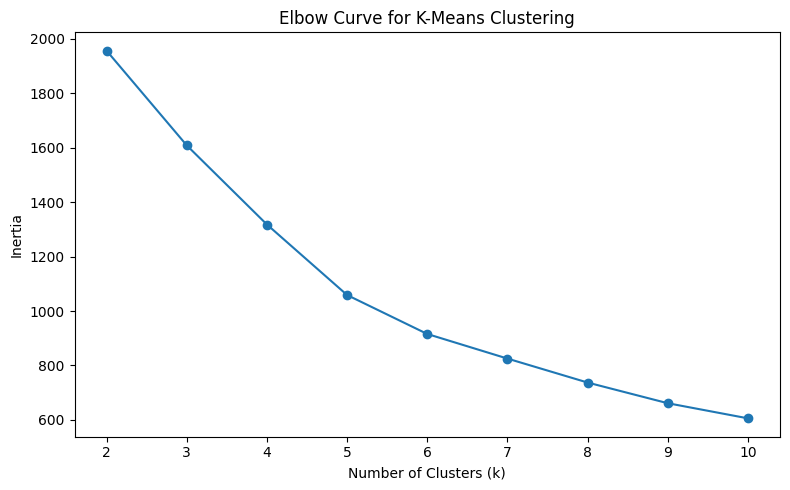

In [13]:
inertia = []

# Calculate inertia for different numbers of clusters
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')

plt.title("Elbow Curve for K-Means Clustering")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

### Observation

The Elbow Curve shows a substantial decrease in inertia as the number of clusters increases from 2 to 5. After k = 5, the reduction in inertia becomes more gradual. Therefore, k = 5 is selected as a suitable number of clusters for the K-Means model.

### 6.2 K-Means Model Training

Based on the Elbow Method, K-Means is fitted with 5 clusters. A fixed random state is used to ensure reproducible results.

In [14]:
# Train the final K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Store the cluster labels
df['KMeans_Cluster'] = kmeans_labels

print("K-Means cluster counts:")
print(df['KMeans_Cluster'].value_counts().sort_index())

K-Means cluster counts:
KMeans_Cluster
0    270
1     10
2     63
3     96
4      1
Name: count, dtype: int64


In [15]:
# Compare clustering quality for k = 4 and k = 5

for k in [4, 5]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    
    print(f"\nk = {k}")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")
    print("Cluster sizes:", np.bincount(labels))


k = 4
Silhouette Score: 0.3485
Davies-Bouldin Index: 1.1475
Calinski-Harabasz Index: 145.8101
Cluster sizes: [110 315  10   5]

k = 5
Silhouette Score: 0.3690
Davies-Bouldin Index: 0.9125
Calinski-Harabasz Index: 162.4134
Cluster sizes: [270  10  63  96   1]


### Observation

The clustering evaluation was performed for k = 4 and k = 5 using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index. The results show that k = 5 achieves a higher Silhouette Score (0.3690), lower Davies-Bouldin Index (0.9125), and higher Calinski-Harabasz Index (162.4134) compared with k = 4.

Although k = 5 provides better internal clustering scores, its cluster distribution includes a very small cluster containing one customer. This indicates that some customers have substantially different purchasing patterns. The cluster distribution will be examined further during cluster interpretation.

In [16]:
# Calculate average spending for each K-Means cluster
cluster_profiles = df.groupby('KMeans_Cluster')[purchase_features].mean()

cluster_profiles

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
KMeans_Cluster,,,,,,
0,9092.155556,2967.759259,3807.411111,2271.759259,989.814815,978.962963
1,15964.900000,34708.500000,48536.900000,3054.600000,24875.200000,2942.800000
2,32957.984127,4997.349206,5884.761905,8422.841270,954.603175,2462.968254
3,5754.166667,10866.604167,16607.104167,1464.125000,7202.875000,1813.385417
4,36847.000000,43950.000000,20170.000000,36534.000000,239.000000,47943.000000


### Observation

The K-Means cluster profiles show distinct purchasing patterns across the five clusters. Cluster 0 represents customers with relatively lower average spending across most product categories, while Cluster 3 shows comparatively higher spending in Milk, Grocery, and Detergents_Paper.

Cluster 2 is characterized by high average Fresh and Frozen spending. Cluster 1 has particularly high average spending on Milk, Grocery, and Detergents_Paper. Cluster 4 contains only one customer and shows exceptionally high spending in several categories, especially Delicassen, Milk, Frozen, and Fresh.

The very small size of Cluster 4 suggests that this customer has a substantially different purchasing pattern from the remaining customers. Therefore, the cluster is retained for further evaluation rather than being removed automatically.

### 6.3 K-Means Evaluation

The K-Means clustering results are evaluated using three internal clustering metrics: Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.

- A higher Silhouette Score indicates better-defined clusters.
- A lower Davies-Bouldin Index indicates better separation between clusters.
- A higher Calinski-Harabasz Index indicates better-defined and well-separated clusters.

In [17]:
# Evaluate the final K-Means clustering
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, kmeans_labels)
kmeans_calinski_harabasz = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {kmeans_calinski_harabasz:.4f}")

Silhouette Score: 0.3690
Davies-Bouldin Index: 0.9125
Calinski-Harabasz Index: 162.4134


### Observation

The K-Means model with 5 clusters achieved a Silhouette Score of 0.3690, a Davies-Bouldin Index of 0.9125, and a Calinski-Harabasz Index of 162.4134. These values provide the baseline clustering performance for comparison with Agglomerative Hierarchical Clustering.

### 6.4 Log Transformation Experiment

The purchasing features are strongly right-skewed, so a log transformation is tested before standardization. `log1p` is used because the purchasing values are non-negative. The transformed features are then standardized and K-Means is fitted with the same 5-cluster configuration for a direct comparison with the original model.

In [18]:
# Apply log transformation followed by standardization
X_log = np.log1p(X)

log_scaler = StandardScaler()
X_log_scaled = log_scaler.fit_transform(X_log)

# Fit K-Means with the same k = 5 for a direct comparison
kmeans_log = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_log_labels = kmeans_log.fit_predict(X_log_scaled)

# Evaluate the log-transformed solution
log_silhouette = silhouette_score(X_log_scaled, kmeans_log_labels)
log_davies_bouldin = davies_bouldin_score(X_log_scaled, kmeans_log_labels)
log_calinski_harabasz = calinski_harabasz_score(X_log_scaled, kmeans_log_labels)

log_comparison = pd.DataFrame({
    'Preprocessing': ['StandardScaler', 'log1p + StandardScaler'],
    'Silhouette Score': [kmeans_silhouette, log_silhouette],
    'Davies-Bouldin Index': [kmeans_davies_bouldin, log_davies_bouldin],
    'Calinski-Harabasz Index': [kmeans_calinski_harabasz, log_calinski_harabasz]
})

log_comparison.round(4)

,Preprocessing,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,StandardScaler,0.3690,0.9125,162.4134
1,log1p + StandardScaler,0.1916,1.4843,118.0005


### Observation

The log-transformed K-Means solution with 5 clusters achieved a Silhouette Score of 0.1916, a Davies-Bouldin Index of 1.4843, and a Calinski-Harabasz Index of 118.0005. Compared with the original StandardScaler-only solution (0.3690, 0.9125, and 162.4134 respectively), the log transformation did not improve the clustering scores for k = 5.

Therefore, the original StandardScaler-based representation is retained for the final clustering analysis. The log transformation was still tested because the purchasing features are strongly right-skewed.

## 7. Agglomerative Hierarchical Clustering

Agglomerative Hierarchical Clustering is used as the second clustering algorithm. It starts by treating each observation as an individual cluster and progressively merges the closest clusters to form a hierarchy.

### 7.1 Dendrogram

A dendrogram is used to visualize the hierarchical merging process and identify a suitable number of clusters.

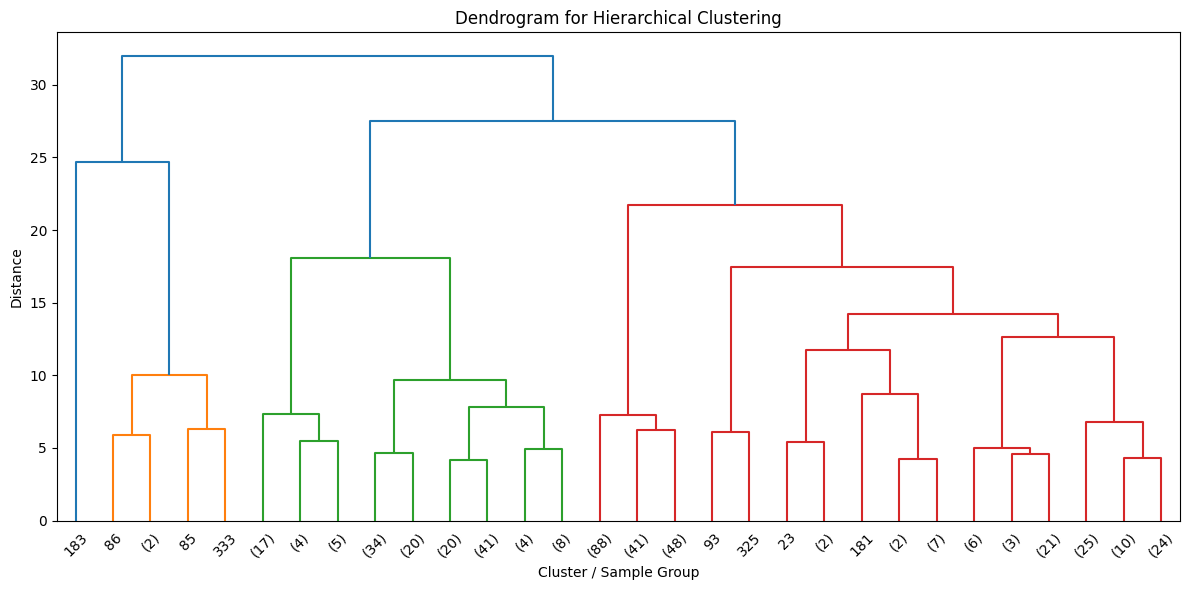

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Compute hierarchical clustering linkage
linkage_matrix = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30
)

plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Cluster / Sample Group")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

### Observation

The dendrogram shows a hierarchical merging structure among the customers, with several larger increases in linkage distance at the higher levels. These larger gaps indicate possible separation between groups of customers. Since the exact number of clusters cannot be determined reliably from the truncated dendrogram alone, multiple cluster counts will be evaluated using the required internal clustering metrics.

### 7.2 Dendrogram Comparison for Linkage Strategies

Ward, Complete, and Average linkage strategies are compared using dendrograms. The three methods use different definitions of distance between clusters, so their merging structures can differ even when the same standardized features are used.

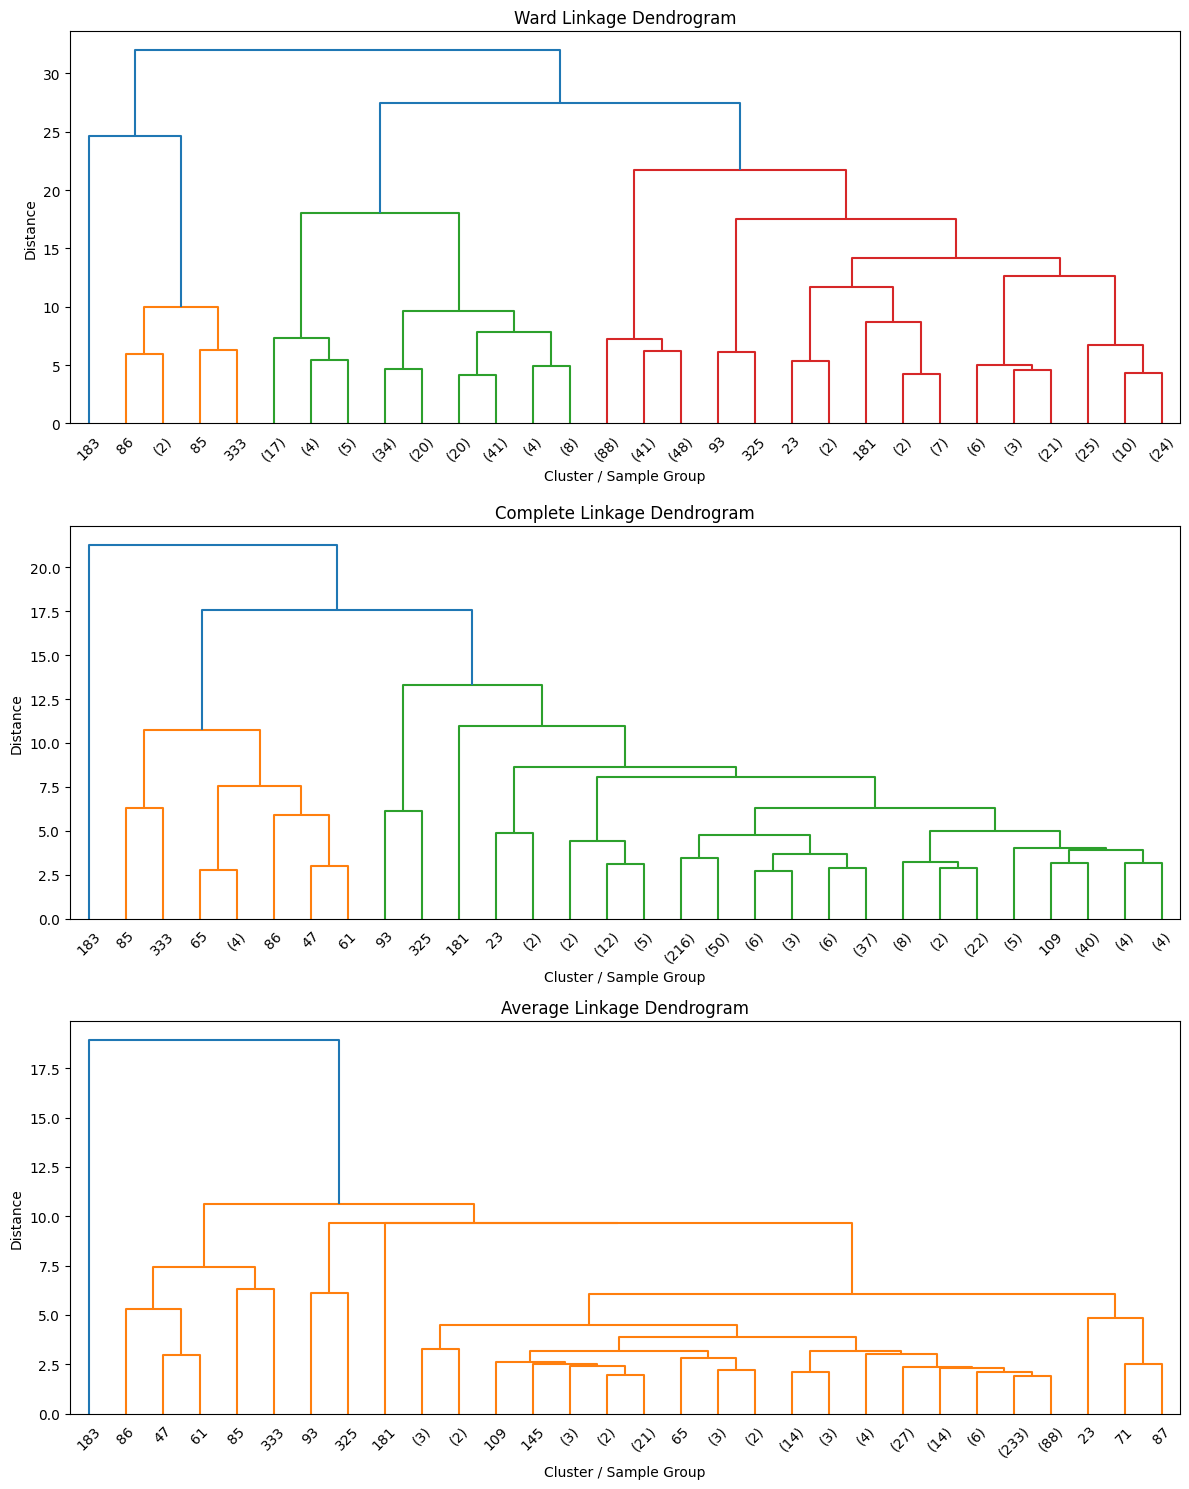

In [20]:
# Compute linkage matrices for three strategies
ward_linkage = linkage(X_scaled, method='ward')
complete_linkage = linkage(X_scaled, method='complete')
average_linkage = linkage(X_scaled, method='average')

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

for ax, matrix, method in zip(
    axes,
    [ward_linkage, complete_linkage, average_linkage],
    ['Ward', 'Complete', 'Average']
):
    dendrogram(
        matrix,
        truncate_mode='lastp',
        p=30,
        ax=ax
    )
    ax.set_title(f"{method} Linkage Dendrogram")
    ax.set_xlabel("Cluster / Sample Group")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

### Observation

The three linkage strategies produce different hierarchical merging patterns. Ward linkage shows the merging structure based on minimizing within-cluster variance, while Complete linkage considers the maximum pairwise distance between clusters and Average linkage uses the average pairwise distance. The dendrograms therefore provide different views of how the customer observations can be hierarchically grouped. Ward linkage is retained for the final model to remain consistent with the selected evaluation pipeline.

### 7.3 Evaluating Different Numbers of Clusters

Agglomerative clustering is evaluated for different numbers of clusters. Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index are used to compare the resulting cluster structures.

In [21]:
hierarchical_results = []

for k in [3, 4, 5]:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    labels = model.fit_predict(X_scaled)
    
    silhouette = silhouette_score(X_scaled, labels)
    davies_bouldin = davies_bouldin_score(X_scaled, labels)
    calinski_harabasz = calinski_harabasz_score(X_scaled, labels)
    
    hierarchical_results.append({
        'Clusters': k,
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies_bouldin,
        'Calinski-Harabasz Index': calinski_harabasz,
        'Cluster Sizes': np.bincount(labels)
    })

hierarchical_results

[{'Clusters': 3,
  'Silhouette Score': 0.2646091480214908,
  'Davies-Bouldin Index': 1.2845213578374577,
  'Calinski-Harabasz Index': 111.15103916524716,
  'Cluster Sizes': array([  6, 281, 153])},
 {'Clusters': 4,
  'Silhouette Score': 0.2670148241989557,
  'Davies-Bouldin Index': 0.9244718793329023,
  'Calinski-Harabasz Index': 120.13148779068312,
  'Cluster Sizes': array([281,   5, 153,   1])},
 {'Clusters': 5,
  'Silhouette Score': 0.23988371669170097,
  'Davies-Bouldin Index': 0.9727210249077043,
  'Calinski-Harabasz Index': 128.64501684791634,
  'Cluster Sizes': array([153,   5, 104,   1, 177])}]

### Observation

The evaluation of Agglomerative Clustering for 3, 4, and 5 clusters shows different results across the three metrics. The 4-cluster solution achieves the highest Silhouette Score (0.2670) and the lowest Davies-Bouldin Index (0.9245), while the 5-cluster solution achieves the highest Calinski-Harabasz Index (128.6450).

The 4-cluster solution is selected for the final hierarchical clustering analysis based on its Silhouette and Davies-Bouldin results. However, the resulting cluster sizes include very small groups, indicating that some customers have substantially different purchasing patterns.

### 7.4 Agglomerative Clustering Model Training

Based on the evaluation of different cluster counts, Agglomerative Hierarchical Clustering is fitted with 4 clusters using Ward linkage.

In [22]:
# Train the final hierarchical clustering model
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Store cluster labels
df['Hierarchical_Cluster'] = hierarchical_labels

print("Hierarchical cluster counts:")
print(df['Hierarchical_Cluster'].value_counts().sort_index())

Hierarchical cluster counts:
Hierarchical_Cluster
0    281
1      5
2    153
3      1
Name: count, dtype: int64


### Observation

The final Agglomerative Clustering model with 4 clusters produces groups of 281, 5, 153, and 1 customers. The majority of customers are grouped into Clusters 0 and 2, while Clusters 1 and 3 contain only a small number of customers.

The small clusters suggest the presence of customers with substantially different purchasing patterns from the majority of the dataset. These observations are retained for evaluation and visualization.

In [23]:
hierarchical_profiles = df.groupby(
    'Hierarchical_Cluster'
)[purchase_features].mean()

hierarchical_profiles

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Hierarchical_Cluster,,,,,,
0,15048.932384,3017.298932,3791.761566,3837.316726,758.007117,1309.900356
1,25603.000000,43460.600000,61472.200000,2636.000000,29974.200000,2708.800000
2,5794.241830,9419.888889,13761.738562,1461.764706,5913.379085,1577.607843
3,36847.000000,43950.000000,20170.000000,36534.000000,239.000000,47943.000000


#### Observation

The hierarchical clustering results show clear differences in purchasing behavior across the four clusters. Cluster 0 represents customers with relatively moderate spending across most categories. Cluster 2 shows higher spending on Milk, Grocery, and Detergents_Paper compared with Cluster 0, indicating a stronger preference toward these categories. Cluster 1 has exceptionally high average spending on Milk, Grocery, and Detergents_Paper, forming a distinct high-spending group. Cluster 3 has very high spending on Fresh, Frozen, and Delicassen, while its Detergents_Paper spending is comparatively low. These differences indicate that the hierarchical clusters capture distinct purchasing patterns among wholesale customers.

### 7.5 Agglomerative Clustering Evaluation

The final Agglomerative Clustering model is evaluated using Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index. These results will later be compared with the K-Means clustering results.

In [24]:
# Evaluate the final hierarchical clustering
hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_davies_bouldin = davies_bouldin_score(
    X_scaled,
    hierarchical_labels
)

hierarchical_calinski_harabasz = calinski_harabasz_score(
    X_scaled,
    hierarchical_labels
)

print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"Davies-Bouldin Index: {hierarchical_davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {hierarchical_calinski_harabasz:.4f}")

Silhouette Score: 0.2670
Davies-Bouldin Index: 0.9245
Calinski-Harabasz Index: 120.1315


## 8. Comparison of Clustering Algorithms

The performance of K-Means and Agglomerative Hierarchical Clustering is compared using the three internal clustering evaluation metrics. Higher values are preferred for the Silhouette Score and Calinski-Harabasz Index, while a lower value is preferred for the Davies-Bouldin Index.

In [25]:
# Create a comparison table for both clustering algorithms
comparison = pd.DataFrame({
    'Algorithm': [
        'K-Means',
        'Agglomerative Hierarchical'
    ],
    'Silhouette Score': [
        kmeans_silhouette,
        hierarchical_silhouette
    ],
    'Davies-Bouldin Index': [
        kmeans_davies_bouldin,
        hierarchical_davies_bouldin
    ],
    'Calinski-Harabasz Index': [
        kmeans_calinski_harabasz,
        hierarchical_calinski_harabasz
    ]
})

comparison.round(4)

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.369,0.9125,162.4134
1,Agglomerative Hierarchical,0.267,0.9245,120.1315


### Observation

K-Means achieved a Silhouette Score of 0.3690, a Davies-Bouldin Index of 0.9125, and a Calinski-Harabasz Index of 162.4134. Agglomerative Hierarchical Clustering achieved a Silhouette Score of 0.2670, a Davies-Bouldin Index of 0.9245, and a Calinski-Harabasz Index of 120.1315.

For this dataset and the selected cluster configurations, K-Means has higher Silhouette and Calinski-Harabasz scores and a lower Davies-Bouldin Index than Agglomerative Clustering. These results indicate stronger internal clustering characteristics for the K-Means solution according to the three evaluation metrics.

## 9. PCA-Based Cluster Visualization

Principal Component Analysis (PCA) is used to reduce the six-dimensional purchasing feature space to two dimensions for visualization. The first two principal components are used to plot the customer clusters while preserving as much of the original variation as possible.

In [26]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 components:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.44082893 0.283764  ]

Total variance explained by 2 components: 0.7245929240774496


### Observation

The first two principal components explain 72.46% of the total variance in the standardized purchasing features. Therefore, the 2D PCA representation retains a substantial portion of the information in the original six-dimensional feature space and can be used to visualize the cluster structure.

### 9.1 PCA Visualization of K-Means Clusters

The K-Means cluster assignments are projected onto the first two principal components to visualize the separation between the identified customer groups.

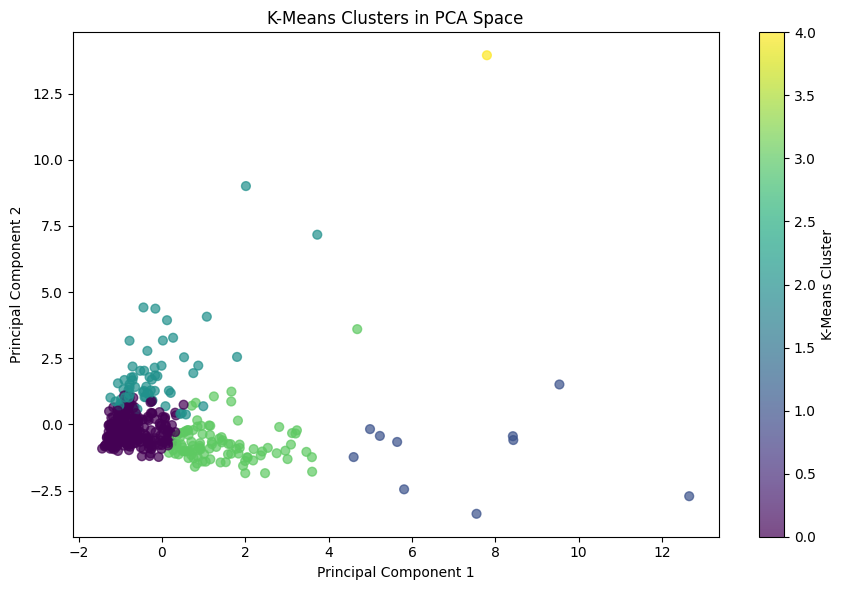

In [27]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=40,
    alpha=0.7
)

plt.title("K-Means Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="K-Means Cluster")

plt.tight_layout()
plt.show()

### Observation

The PCA scatter plot shows that most K-Means observations are concentrated around the central region, mainly around Principal Component 1 values from approximately -1 to 2 and Principal Component 2 values from approximately -1 to 2. A smaller number of observations extend farther along the principal components, representing customers with more distinct purchasing patterns.

### 9.2 PCA Visualization of Hierarchical Clusters

The Agglomerative Hierarchical Clustering assignments are projected onto the same two principal components to visualize the resulting customer groups and compare their structure with the K-Means clusters.

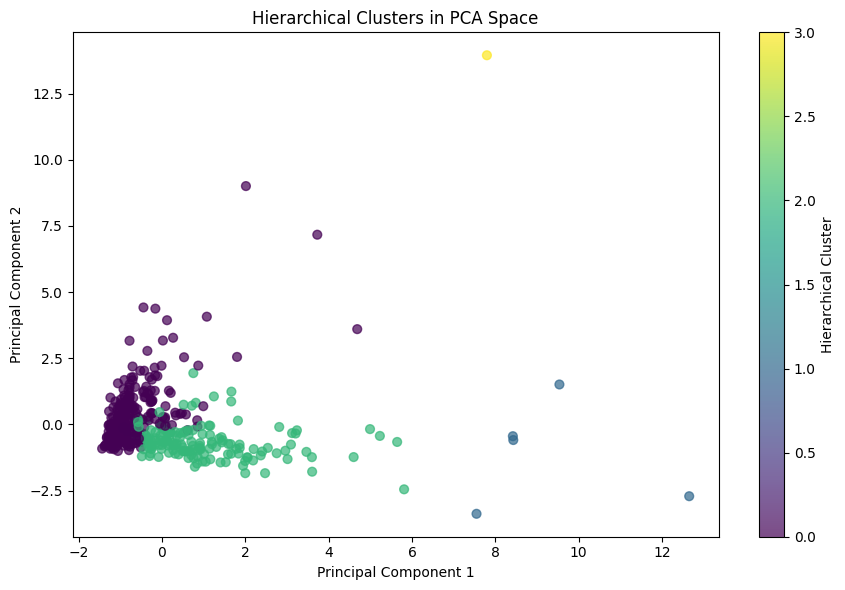

In [28]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    cmap='viridis',
    s=40,
    alpha=0.7
)

plt.title("Hierarchical Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Hierarchical Cluster")

plt.tight_layout()
plt.show()

### Observation

The PCA scatter plot shows that most Agglomerative Hierarchical observations are concentrated around the central region, mainly around Principal Component 1 values from approximately -1 to 2 and Principal Component 2 values from approximately -1 to 2. A smaller number of observations extend farther from this region, corresponding to customers with distinct purchasing patterns.

### 9.3 t-SNE Visualization of K-Means Clusters

t-SNE (t-distributed Stochastic Neighbor Embedding) is used to obtain a two-dimensional representation of the customer purchasing data. Unlike PCA, t-SNE focuses on preserving local neighborhood relationships and can help visualize patterns that may not be clearly visible in a linear PCA projection.

The K-Means cluster labels are used to colour the resulting two-dimensional representation.

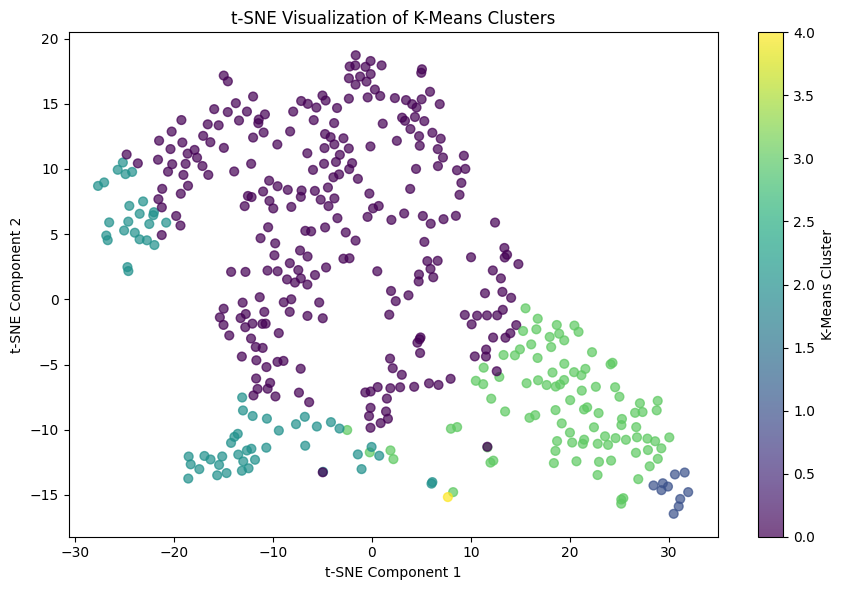

In [29]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=40,
    alpha=0.7
)

plt.title("t-SNE Visualization of K-Means Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(label="K-Means Cluster")

plt.tight_layout()
plt.show()

### Observation

The t-SNE representation provides an additional view of the local structure of the customer data. The K-Means labels show how the identified clusters are distributed in this nonlinear two-dimensional representation. It reveals distinct regions, particularly for the smaller clusters, while the largest cluster occupies a broader portion of the representation.

Compared with PCA, t-SNE provides a different view of the local structure of the customer data and helps highlight groups of customers with similar purchasing patterns.